          date  fwd_ret_1  fwd_ret_5  fwd_ewm_ret_5  fwd_ewm_ret_20  \
238 2024-11-27   1.695897   1.416835       1.263581        1.173265   
239 2024-11-28   1.690731   1.409696       1.264934        1.174974   
240 2024-11-29   1.693336   1.404960       1.262420        1.174678   
241 2024-12-02   1.712669   1.417087       1.265579        1.177762   
242 2024-12-03   1.716840   1.411760       1.263364        1.173029   

     fwd_ret_5_voladj  fwd_ret_20_voladj  fwd_ret_1_rank  fwd_ret_5_rank  
238          1.182842           1.198292        1.233742        1.232375  
239          1.189123           1.199485        1.232875        1.227167  
240          1.197987           1.202100        1.232715        1.217408  
241          1.201731           1.204223        1.243867        1.220573  
242          1.207578           1.206032        1.246560        1.222330  


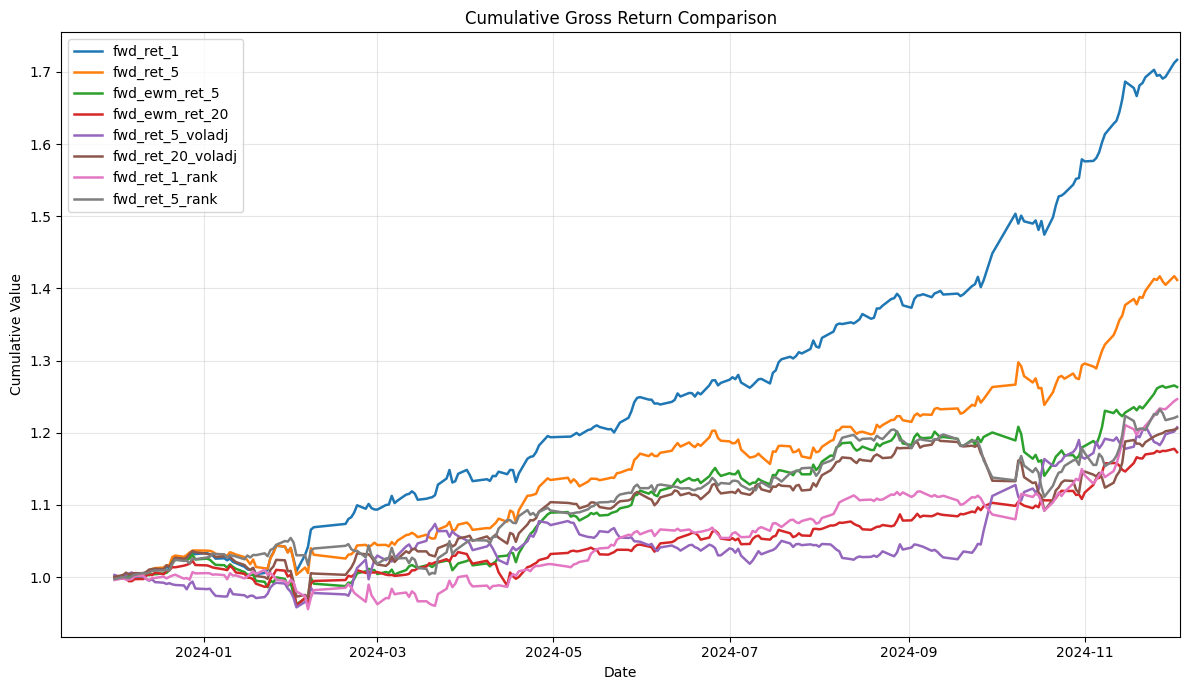

In [43]:
from __future__ import annotations

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

# =========================
# 1. 配置区
# =========================
# 每个根目录下面可以放多个策略名
PORTFOLIO_CONFIG: dict[str, list[str]] = {
    r"D:\python\graduation_thesis\predict_return":['fwd_ret_1', 'fwd_ret_5', 'fwd_ewm_ret_5', 'fwd_ewm_ret_20',
               'fwd_ret_5_voladj', 'fwd_ret_20_voladj', 'fwd_ret_1_rank',
                'fwd_ret_5_rank',],
    r"D:\python\graduation_thesis\combo_predict_return": [
        # "adj5", "adj20",   "ewm5",  "ewm20", "vol5", "vol20",
        # "ewm20_rank5", "ewm520", "vol_voladj5","ewm5_voladj20", "vol_voladj20",  "vol520", "voladj520","ewm_voladj20",
        ]
}

RETURN_COL = "gross_return"
DATE_COL = "date"
FILE_NAME = "daily_perf.parquet"
START_VALUE = 1.0

TITLE = "Cumulative Gross Return Comparison"
YLABEL = "Cumulative Value"
FIGSIZE = (12, 7)

SAVE_PATH = r"D:\python\graduation_thesis\plots\diff_label.png"


# 2. 展开配置
def expand_config(
    portfolio_config: dict[str, list[str]],
    file_name: str = "daily_perf.parquet",
) -> dict[str, str]:
    """
    把
        {base_dir: [name1, name2]}
    展开成
        {full_path: display_name}
    """
    expanded: dict[str, str] = {}

    for base_dir, names in portfolio_config.items():
        for name in names:
            full_path = str(Path(base_dir) / name / file_name)
            expanded[full_path] = name

    return expanded


# 3. 读取单条曲线
def load_one_curve(
    file_path: str,
    display_name: str,
    date_col: str = "date",
    return_col: str = "gross_return",
    start_value: float = 1.0,
) -> pd.DataFrame:
    df = pd.read_parquet(file_path)

    required_cols = {date_col, return_col}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"{file_path} 缺少列: {missing}")

    out = df[[date_col, return_col]].copy()
    out[date_col] = pd.to_datetime(out[date_col])
    out = out.sort_values(date_col).drop_duplicates(subset=[date_col], keep="first")
    out[return_col] = out[return_col].fillna(0.0)

    out[display_name] = start_value * (1.0 + out[return_col]).cumprod()

    return out[[date_col, display_name]]


# 4. 合并所有曲线
def build_curve_panel(
    expanded_config: dict[str, str],
    date_col: str = "date",
    return_col: str = "gross_return",
    start_value: float = 1.0,
) -> pd.DataFrame:
    merged = None

    for file_path, display_name in expanded_config.items():
        curve = load_one_curve(
            file_path=file_path,
            display_name=display_name,
            date_col=date_col,
            return_col=return_col,
            start_value=start_value,
        )

        if merged is None:
            merged = curve
        else:
            merged = merged.merge(curve, on=date_col, how="outer")

    if merged is None:
        raise ValueError("没有可用组合，请检查 PORTFOLIO_CONFIG。")

    merged = merged.sort_values(date_col).reset_index(drop=True)

    value_cols = [c for c in merged.columns if c != date_col]
    merged[value_cols] = merged[value_cols].ffill()

    return merged



# 5. 画图
def plot_cumulative_returns(
    panel: pd.DataFrame,
    date_col: str = "date",
    title: str = "Cumulative Return Comparison",
    ylabel: str = "Cumulative Value",
    figsize: tuple[int, int] = (12, 7),
    save_path: str | None = None,
) -> None:
    plt.figure(figsize=figsize)

    value_cols = [c for c in panel.columns if c != date_col]
    for col in value_cols:
        plt.plot(panel[date_col], panel[col], label=col, linewidth=1.8)

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.xlim(None,dt.datetime(2024, 12, 4))
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

# 6. 主程序
if __name__ == "__main__":
    expanded_config = expand_config(PORTFOLIO_CONFIG, file_name=FILE_NAME)

    panel = build_curve_panel(
        expanded_config=expanded_config,
        date_col=DATE_COL,
        return_col=RETURN_COL,
        start_value=START_VALUE,
    )

    print(panel.tail())

    plot_cumulative_returns(
        panel=panel,
        date_col=DATE_COL,
        title=TITLE,
        ylabel=YLABEL,
        figsize=FIGSIZE,
        save_path=SAVE_PATH,
    )

           portfolio    sharpe  avg_daily_turnover  max_drawdown
0          fwd_ret_1  4.674861            0.316036     -0.035210
1          fwd_ret_5  2.830000            0.288612     -0.047543
2      fwd_ewm_ret_5  1.845331            0.281604     -0.073182
3     fwd_ret_1_rank  1.677176            0.288336     -0.059773
4     fwd_ret_5_rank  1.506389            0.208085     -0.083760
5  fwd_ret_20_voladj  1.363960            0.219990     -0.087829
6     fwd_ewm_ret_20  1.300496            0.253031     -0.066837
7   fwd_ret_5_voladj  1.213330            0.258086     -0.074692
8         fwd_vol_20  0.252161            0.133329     -0.185442
9          fwd_vol_5  0.179204            0.145461     -0.184517


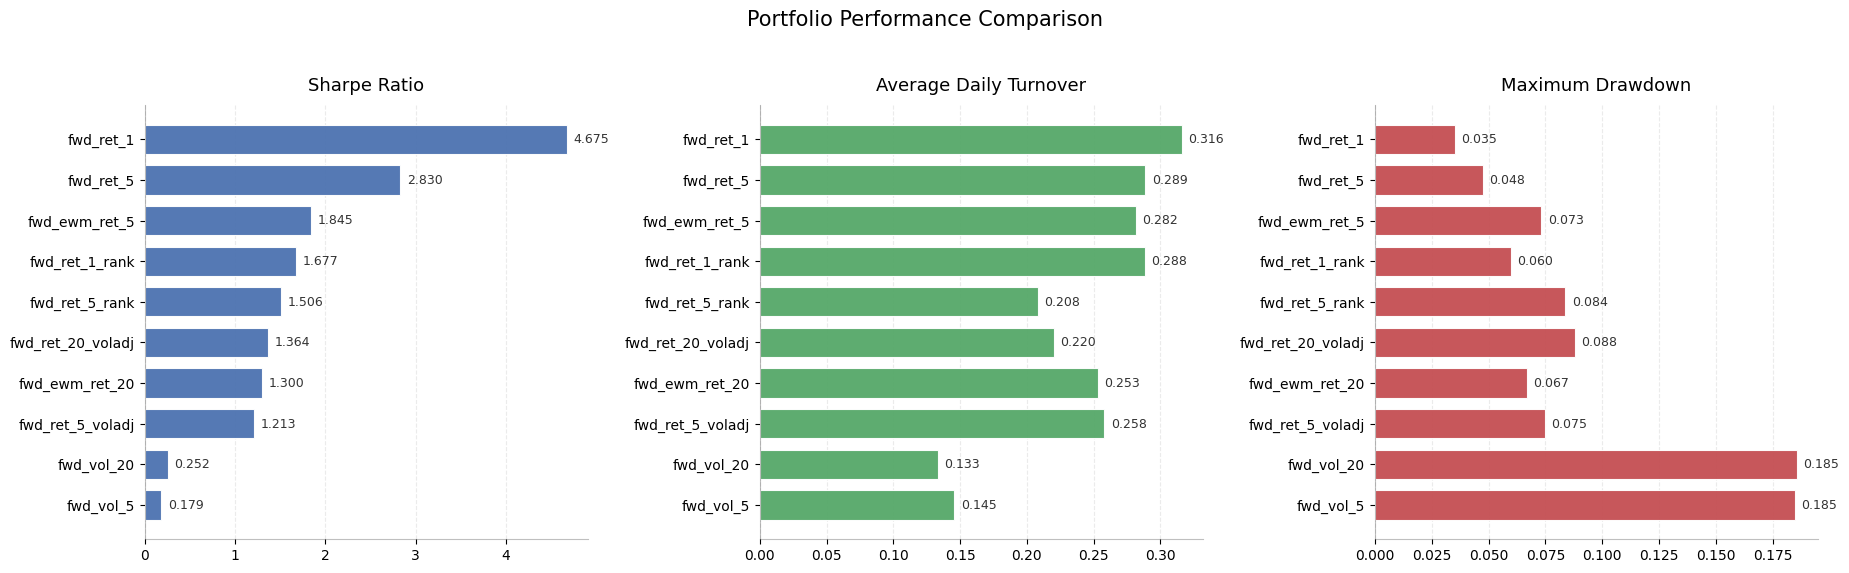

In [7]:
from __future__ import annotations

from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt


# =========================
# 1. 配置区
# =========================
PORTFOLIO_CONFIG: dict[str, list[str]] = {
    r"D:\python\graduation_thesis\combo_predict_return": [
        # "adj5", "adj20", "ewm5", "ewm20", "vol5", "vol20",
        # "ewm20_rank5", "ewm520", "vol_voladj5","ewm5_voladj20", "vol_voladj20", "vol520", "voladj520","ewm_voladj20",
    ],
    r"D:\python\graduation_thesis\predict_return": ['fwd_ret_1', 'fwd_ret_5', 'fwd_ewm_ret_5', 'fwd_ewm_ret_20',
               'fwd_ret_5_voladj', 'fwd_ret_20_voladj', 'fwd_ret_1_rank',
                'fwd_ret_5_rank','fwd_vol_5','fwd_vol_20'],
}

SUMMARY_FILE = "summary.json"
METRICS = ["sharpe", "avg_daily_turnover", "max_drawdown"]

TITLE = "Portfolio Performance Comparison"
SAVE_PATH = r"D:\python\graduation_thesis\plots\summary_metrics_comparison.png"

SORT_BY = "sharpe"
SORT_ASCENDING = False


# =========================
# 2. 展开配置
# =========================
def expand_config(
    portfolio_config: dict[str, list[str]],
    file_name: str = "summary.json",
) -> dict[str, str]:
    expanded: dict[str, str] = {}
    for base_dir, names in portfolio_config.items():
        for name in names:
            full_path = str(Path(base_dir) / name / file_name)
            expanded[full_path] = name
    return expanded


# =========================
# 3. 读取单个 summary.json
# =========================
def load_one_summary(
    file_path: str,
    display_name: str,
    metrics: list[str],
) -> dict:
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"文件不存在: {path}")

    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    row = {"portfolio": display_name}
    for metric in metrics:
        if metric not in data:
            raise KeyError(f"{path} 中缺少指标: {metric}")
        row[metric] = data[metric]

    return row


# =========================
# 4. 构建指标表
# =========================
def build_summary_panel(
    expanded_config: dict[str, str],
    metrics: list[str],
) -> pd.DataFrame:
    rows = []
    for file_path, display_name in expanded_config.items():
        row = load_one_summary(
            file_path=file_path,
            display_name=display_name,
            metrics=metrics,
        )
        rows.append(row)

    if not rows:
        raise ValueError("没有读到任何 summary.json")

    df = pd.DataFrame(rows)
    return df


# =========================
# 5. 画横向对比图（3个子图）
# =========================
def plot_summary_metrics(
    df: pd.DataFrame,
    metrics: list[str],
    title: str = "Portfolio Performance Comparison",
    save_path: str | None = None,
) -> None:
    df_plot = df.copy()

    # MDD 改成绝对值，图上更直观
    if "max_drawdown" in df_plot.columns:
        df_plot["max_drawdown"] = df_plot["max_drawdown"].abs()

    n_metrics = len(metrics)
    fig, axes = plt.subplots(
        1,
        n_metrics,
        figsize=(6.2 * n_metrics, max(5.8, 0.5 * len(df_plot))),
        constrained_layout=False,
    )
    if n_metrics == 1:
        axes = [axes]

    portfolio_names = df_plot["portfolio"]

    metric_title_map = {
        "sharpe": "Sharpe Ratio",
        "avg_daily_turnover": "Average Daily Turnover",
        "max_drawdown": "Maximum Drawdown",
    }

    # 更丰富一点但不花的配色
    metric_color_map = {
        "sharpe": "#4C72B0",             # 蓝
        "avg_daily_turnover": "#55A868", # 绿
        "max_drawdown": "#C44E52",       # 红
    }

    for ax, metric in zip(axes, metrics):
        values = df_plot[metric]
        color = metric_color_map.get(metric, "#4C72B0")

        ax.barh(
            portfolio_names,
            values,
            color=color,
            edgecolor="white",
            linewidth=0.8,
            alpha=0.95,
            height=0.72,
        )

        ax.set_title(metric_title_map.get(metric, metric), fontsize=13, pad=10)
        ax.grid(axis="x", linestyle="--", alpha=0.25, linewidth=0.8)
        ax.set_axisbelow(True)
        ax.invert_yaxis()

        # 去掉上右边框，整体更干净
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_alpha(0.25)
        ax.spines["bottom"].set_alpha(0.25)

        ax.tick_params(axis="y", labelsize=10)
        ax.tick_params(axis="x", labelsize=10)

        # 数值标签
        x_min, x_max = ax.get_xlim()
        x_range = x_max - x_min if x_max > x_min else 1.0
        offset = x_range * 0.015

        for y, v in enumerate(values):
            ax.text(
                v + offset,
                y,
                f"{v:.3f}",
                va="center",
                ha="left",
                fontsize=9,
                color="#333333",
            )

    fig.suptitle(title, fontsize=15, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=220, bbox_inches="tight")

    plt.show()


# =========================
# 6. 主程序
# =========================
if __name__ == "__main__":
    expanded_config = expand_config(PORTFOLIO_CONFIG, file_name=SUMMARY_FILE)

    df = build_summary_panel(
        expanded_config=expanded_config,
        metrics=METRICS,
    )

    if SORT_BY is not None:
        df = df.sort_values(SORT_BY, ascending=SORT_ASCENDING).reset_index(drop=True)

    print(df)

    plot_summary_metrics(
        df=df,
        metrics=METRICS,
        title=TITLE,
        save_path=SAVE_PATH,
    )

In [14]:
from pathlib import Path
import pandas as pd
import statsmodels.api as sm


# =========================
# 1. 配置区
# =========================
portfolio_path = Path(r"D:\python\graduation_thesis\combo_predict_return\ewm20_rank5\daily_perf.parquet")
benchmark_path = Path(r"D:\python\graduation_thesis\predict_return\fwd_ret_1\daily_perf.parquet")
factor_path = Path(r"D:\python\graduation_thesis\5f.csv")

# 可选:
# "benchmark"      -> ret ~ benchmark
# "factor"         -> ret ~ 5 factors
# "both"           -> ret ~ benchmark + 5 factors
MODE = "both"

RETURN_COL = "net_return"
DATE_COL = "date"


# =========================
# 2. 读取数据函数
# =========================
def load_return_series(path: Path, return_col: str = "net_return", date_col: str = "date") -> pd.DataFrame:
    df = pd.read_parquet(path)[[date_col, return_col]].copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).drop_duplicates(date_col, keep="first")
    return df


def load_factor_data(path: Path, date_col: str = "date") -> pd.DataFrame:
    fac = pd.read_csv(path)
    fac[date_col] = pd.to_datetime(fac[date_col])
    fac = fac.sort_values(date_col).drop_duplicates(date_col, keep="first")
    return fac


def detect_factor_cols(fac: pd.DataFrame) -> list[str]:
    candidate_order = ["RiskPremium1", "SMB1", "HML1", "RMW1", "CMA1"]
    factor_cols = [c for c in candidate_order if c in fac.columns]
    if len(factor_cols) == 0:
        raise ValueError(f"没有识别到五因子列，请检查列名：{fac.columns.tolist()}")
    return factor_cols


# =========================
# 3. 主回归函数
# =========================
def run_regression(
    portfolio_path: Path,
    benchmark_path: Path,
    factor_path: Path,
    mode: str = "both",
    return_col: str = "net_return",
    date_col: str = "date",
):
    # 组合收益
    port = load_return_series(portfolio_path, return_col, date_col).rename(
        columns={return_col: "port_ret"}
    )

    # benchmark
    bench = load_return_series(benchmark_path, return_col, date_col).rename(
        columns={return_col: "bench_ret"}
    )

    # 五因子
    fac = load_factor_data(factor_path, date_col)
    factor_cols = detect_factor_cols(fac)

    # 合并
    df = port.merge(bench, on=date_col, how="inner")
    df = df.merge(fac[[date_col] + factor_cols], on=date_col, how="inner")
    df = df.dropna().reset_index(drop=True)

    # 选自变量
    if mode == "benchmark":
        x_cols = ["bench_ret"]
    elif mode == "factor":
        x_cols = factor_cols
    elif mode == "both":
        x_cols = ["bench_ret"] + factor_cols
    else:
        raise ValueError("mode 只能是 'benchmark'、'factor' 或 'both'")

    y = df["port_ret"]*1e4
    X = sm.add_constant(df[x_cols]*1e4)

    model = sm.OLS(y, X).fit(cov_type="HC3")

    print("\n" + "=" * 90)
    print(f"Regression Mode: {mode}")
    print("=" * 90)
    print(f"portfolio   : {portfolio_path}")
    print(f"benchmark   : {benchmark_path}")
    print(f"factor file : {factor_path}")
    print(f"X cols      : {x_cols}")
    print(f"nobs        : {len(df)}")
    print(model.summary())

    alpha = model.params["const"]
    alpha_t = model.tvalues["const"]
    alpha_p = model.pvalues["const"]
    r2 = model.rsquared
    adj_r2 = model.rsquared_adj

    print("\n===== Key Results =====")
    print(f"daily alpha     : {alpha:.8f}")
    print(f"annualized alpha: {alpha * 252:.6f}")
    print(f"alpha t-stat    : {alpha_t:.4f}")
    print(f"alpha p-value   : {alpha_p:.6f}")
    print(f"R-squared       : {r2:.4f}")
    print(f"Adj. R-squared  : {adj_r2:.4f}")

    coef_table = pd.DataFrame({
        "coef": model.params,
        "std_err": model.bse,
        "t_or_z": model.tvalues,
        "p_value": model.pvalues,
        "ci_low": model.conf_int()[0],
        "ci_high": model.conf_int()[1],
    })

    print("\n===== Coefficient Table =====")
    print(coef_table.round(6))

    return {
        "mode": mode,
        "x_cols": x_cols,
        "nobs": len(df),
        "alpha_daily": alpha,
        "alpha_annual": alpha * 252,
        "alpha_t": alpha_t,
        "alpha_p": alpha_p,
        "r2": r2,
        "adj_r2": adj_r2,
        "model": model,
        "data": df,
    }


# =========================
# 4. 主程序
# =========================
if __name__ == "__main__":
    results = run_regression(
        portfolio_path=portfolio_path,
        benchmark_path=benchmark_path,
        factor_path=factor_path,
        mode=MODE,
        return_col=RETURN_COL,
        date_col=DATE_COL,
    )
    



Regression Mode: both
portfolio   : D:\python\graduation_thesis\combo_predict_return\ewm20_rank5\daily_perf.parquet
benchmark   : D:\python\graduation_thesis\predict_return\fwd_ret_1\daily_perf.parquet
factor file : D:\python\graduation_thesis\5f.csv
X cols      : ['bench_ret', 'RiskPremium1', 'SMB1', 'HML1', 'RMW1', 'CMA1']
nobs        : 243
                            OLS Regression Results                            
Dep. Variable:               port_ret   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     44.58
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           3.03e-36
Time:                        15:58:14   Log-Likelihood:                -1110.3
No. Observations:                 243   AIC:                             2235.
Df Residuals:                     236   BIC:                             2259.
Df Model:             

In [15]:
import pandas as pd
import numpy as np

res = results['model']   # 你的 statsmodels 回归结果

coef = res.params
se = res.bse
pval = res.pvalues
ci = res.conf_int()
n = int(res.nobs)
r2 = res.rsquared
adj_r2 = res.rsquared_adj

name_map = {
    "const": "Alpha",
    "RiskPremium1": "MKT",
    "SMB1": "SMB",
    "HML1": "HML",
    "RMW1": "RMW",
    "CMA1": "CMA"
}

def stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.1:
        return "*"
    return ""

rows = []
for var in coef.index:
    vname = name_map.get(var, var)
    rows.append([vname, f"{coef[var]:.4f}{stars(pval[var])}"])
    rows.append(["", f"({se[var]:.4f})"])

table = pd.DataFrame(rows, columns=["Variable", "Model (1)"])

# 底部统计量
stats_rows = pd.DataFrame([
    ["Observations", f"{n}"],
    ["$R^2$", f"{r2:.3f}"],
    ["Adj. $R^2$", f"{adj_r2:.3f}"]
], columns=["Variable", "Model (1)"])

final_table = pd.concat([table, stats_rows], ignore_index=True)

latex_str = final_table.to_latex(
    index=False,
    escape=False,
    column_format="lc"
)

with open("plots/factor_reg.tex", "w", encoding="utf-8") as f:
    f.write(latex_str)